# Step 1: Import Libraries

Import libraries used in the project.

* pandas → read dataset  
* numpy → numerical operations  
* matplotlib, seaborn → visualization  
* re → text cleaning

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Step 2: Read Dataset

Load the dataset using pandas.

read_csv() → reads the CSV file and creates a dataframe.

In [5]:
df = pd.read_csv("fake_news.csv")

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


# Step 3: Check Dataset Shape

Check the size of the dataset.

shape → shows number of rows and columns.

In [6]:
df.shape

(72134, 4)

# Step 4: Dataset Information

Check the structure of the dataset.

info() → shows columns, data types, and missing values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


# Step 5: Remove Unnecessary Column

The column "Unnamed: 0" is only an index column.
It is not useful for our model.

So we remove this column from the dataset.

In [8]:
df = df.drop("Unnamed: 0", axis=1)

df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


# Step 6: Check Missing Values

Check if the dataset contains missing values.

isnull() → finds missing values  
sum() → counts them

In [9]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

# Step 7: Remove Missing Values

Remove rows that contain missing values.

dropna() removes all rows where data is missing.

In [10]:
df = df.dropna()

df.isnull().sum()

title    0
text     0
label    0
dtype: int64

# Step 8: Combine Title and Text

Combine title and text into one column.

This helps the model use both headline and article content.

In [11]:
df["content"] = df["title"] + " " + df["text"]

df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,About Time! Christian Group Sues Amazon and SP...


# Step 9: Text Cleaning

Clean the news text before training the model.

Convert text to lowercase  
Remove punctuation and special characters

In [12]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text

# Step 10: Apply Text Cleaning

Apply the cleaning function to the content column.

apply() runs the function on every row of the column.

In [13]:
df["content"] = df["content"].apply(clean_text)

df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement on high alert following threat...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama s attorney general says mos...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu uses story of christ...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan 2 russia unvelis an image of its terrify...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,about time christian group sues amazon and spl...


# Step 11: Remove Stopwords

Stopwords are common words that do not add much meaning.

Examples:
the, is, and, in, of

Removing stopwords helps the model focus on important words.

In [14]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tirupati\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Step 12: Remove Stopwords

Create a function to remove stopwords from text.

The function splits the text into words and removes common words.

In [15]:
def remove_stopwords(text):
    
    words = text.split()
    
    filtered_words = [word for word in words if word not in stop_words]
    
    return " ".join(filtered_words)

# Step 13: Apply Stopwords Removal

Apply the stopwords removal function to the content column.

This removes common words from the news text.

In [16]:
df["content"] = df["content"].apply(remove_stopwords)

df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threats c...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general says charl...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu uses story christian...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan 2 russia unvelis image terrifying new su...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sues amazon splc designat...


# Step 14: TF-IDF Feature Engineering

Machine learning models cannot understand text.

So we convert text into numbers using TF-IDF.

TF-IDF gives higher weight to important words.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

X = vectorizer.fit_transform(df["content"])

y = df["label"]

# Step 15: Train Test Split

Split the dataset into training and testing data.

Training data → used to train the model  
Testing data → used to evaluate the model

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 16: Train Model

Train a machine learning model using Logistic Regression.

Logistic Regression is a popular algorithm for text classification tasks.

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Step 17: Model Prediction

Use the trained model to predict labels for the test data.

The model will classify news as:
0 → Fake
1 → Real

In [37]:
y_pred = model.predict(X_test)

y_pred

array([1, 0, 0, ..., 1, 0, 1], shape=(14308,))

# Step 18: Model Evaluation

Evaluate the model performance.

Accuracy → how many predictions are correct  
Classification Report → shows precision, recall and f1-score

In [38]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.9549902152641878
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7081
           1       0.95      0.96      0.96      7227

    accuracy                           0.95     14308
   macro avg       0.96      0.95      0.95     14308
weighted avg       0.96      0.95      0.95     14308



# Check Train Accuracy

Compare training accuracy with test accuracy to detect overfitting.

In [39]:
train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.9693337294029251


# Step 19: Fake vs Real News Distribution

Bar chart showing the number of fake and real news articles in the dataset.

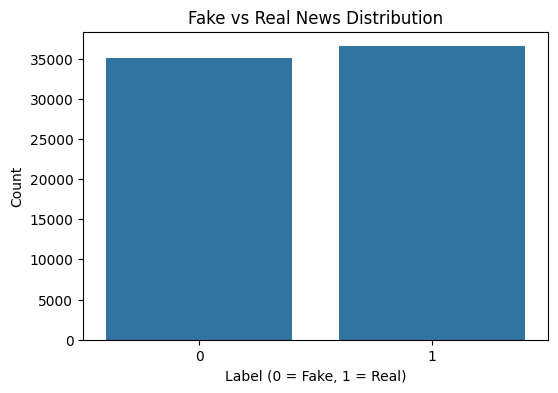

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Count")

plt.show()

# Step 20: Labeled Confusion Matrix

This graph shows the confusion matrix with labels:
TP, TN, FP, FN.

It helps explain how the model predicts Fake and Real news.

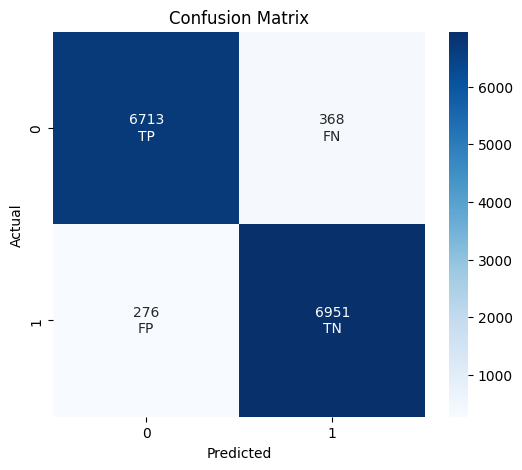

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

labels = np.array([
    [f"{cm[0,0]}\nTP", f"{cm[0,1]}\nFN"],
    [f"{cm[1,0]}\nFP", f"{cm[1,1]}\nTN"]
])

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Confusion Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Step 20: ROC Curve

ROC Curve shows how well the model separates fake and real news.

AUC score measures the overall performance of the model.

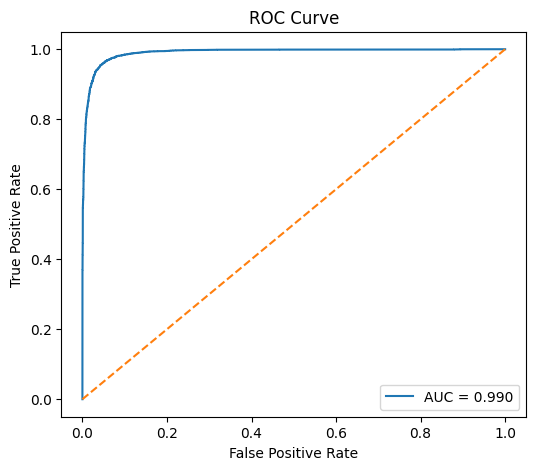

In [42]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

# Step 21: Save Model

Save the trained model and TF-IDF vectorizer.

These files will be used later in the Streamlit web application.

In [43]:
import pickle

# save model
pickle.dump(model, open("fake_news_model.pkl", "wb"))

# save vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

# Step 23: Streamlit Web App

Create a web interface where users can enter news text and check if it is Fake or Real.